In [1]:
# Standard imports
import os
import sys
import matplotlib.pyplot as plt
import numpy as np

In [2]:
sys.path.append(r"/mnt/data/the_deep/Geotech_Research/Critical_Soil_Models/pumat")

from lib.Load_Classes.Popular_Load_Class import PopularPath
from lib.Driver_Classes.Mod_Driver_Setup import DriverModelSetup
from lib.Driver_Classes.Mod_Driver_Model import DriverModel
from lib.general_functions.executing_runs import generate_batch_script, run_batch_script

In [30]:
trx_strain = "TriaxialE1"

load_params = {
    "ninc": 1000,
    "maxiter": 200,
    "dtime"  : 0.01,
    "every"  : 10,
    "ddstran_1": 0.2,
}


load = PopularPath(trx_strain, load_params)

In [31]:
# This needs to be in the order that the parameters should be in

Newton_Raphson_Props = {
    "Init Shear Modulus" : 2500,
    "poisson ratio"      : 0.2,
    "M_tc"               : 1,
    "Nova's N"           : 0.0,
    "D_min"              : 0.0,
    "h"                  : 0,
    "alpha_K"            : 0.0,
    "alpha_G"            : 0.0, 
    "alpha_D"            : 0.0,
    "D_part"             : 0.0, 
    "G_s"                : 0.0,
    "ref_rate"           : 0.0,
    "switch_smooth"      : 0.0, 
    "Num smoothing"      : 0.0,
    "switch original"    : 0.0,
    "FTOl"               : 1e-8,
    "max stress iters"   : 1000,
    "switch_plastic_integration": 0# 0 for substepping and 1 for ortiz-Simo
}

# Store a copy of the properties
Ortiz_Simo_Props = Newton_Raphson_Props.copy()

# Change the integration flag to be Ortiz-Simo integration
Ortiz_Simo_Props["switch_plastic_integration"] = 1

In [32]:
# Get the name of the current folder
current_working_dir = os.getcwd()

# Path to the folder that the Ortiz-Simo data should be stored in
Ortiz_Simo = os.path.join(current_working_dir, "Ortiz_Simo")
Newton_Raphson = os.path.join(current_working_dir, "Newton_Raphson")

exe_path = r"/mnt/data/the_deep/Geotech_Research/Critical_Soil_Models/Strain_Rate_Mohr_Coulomb/build/gfortran_427241F60AE421C3/app/SRMC_incrementalDriver"


In [33]:
# Generate the 
models = [DriverModel(Ortiz_Simo, "Ortiz_Simo", exe_path, "output.txt"),
          DriverModel(Newton_Raphson, "Newton Raphson", exe_path, "output.txt")
]

# Make a list of the properties and store them for later. Needs to be in the same order as the above models list
properties = [Ortiz_Simo_Props, Newton_Raphson_Props]

In [34]:
for model in models:
    model.setup.clear_folder()

Deleted: /mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/2_perf_plastic/Ortiz_Simo/initialconditions.inp
Deleted: /mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/2_perf_plastic/Ortiz_Simo/test.inp
Deleted: /mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/2_perf_plastic/Ortiz_Simo/parameters.inp
Deleted: /mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/2_perf_plastic/Ortiz_Simo/run_model.bat
Deleted: /mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/2_perf_plastic/Ortiz_Simo/output.txt
Deleted: /mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/2_perf_plastic/Newton_Raphson/initialconditions.inp
Deleted: /mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/2_perf_plastic/Newton_Raphson/test.inp
Deleted: /mnt/data/the

In [35]:

for model, props in zip(models, properties):
    model.setup.write_parameters_file(props)


In [41]:
# Set the stress and state parameters
stress = [100, 100, 100, 0, 0, 0]
state_params = {"shear modulus"       : 0,
                "bulk modulus"        : 0,
                "Stress ratio"        : 0,
                "Dilatancy"           : 0,
                "Inertial Coeff"      : 0,
                "yielding (1 for yes)": 0,
                "EspP_1"              : 0,
                "EspP_2"              : 0,
                "EspP_3"              : 0,
                "EspP_4"              : 0,
                "EspP_5"              : 0,
                "EspP_6"              : 0,
                "N_i"                 : 0, # Current number of strain rate sums
                "Sum_rate"            : 0  # Current sum of strain rates 
}

for model in models:
    model.setup.write_initial_conditions_file(stress, state_params)
    model.setup.store_loads(load)
    model.setup.write_loads()

In [42]:
for model in models:
    model.run_model()

Batch file '/mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/2_perf_plastic/Ortiz_Simo/run_model.bat' executed successfully.
Batch file '/mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/2_perf_plastic/Newton_Raphson/run_model.bat' executed successfully.


In [43]:
for model in models:
    print(model.results)

Output file name: output.txt
Results folder path: /mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/2_perf_plastic/Ortiz_Simo

Output file name: output.txt
Results folder path: /mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/2_perf_plastic/Newton_Raphson



In [44]:
for model in models:
    model.results.store_all()

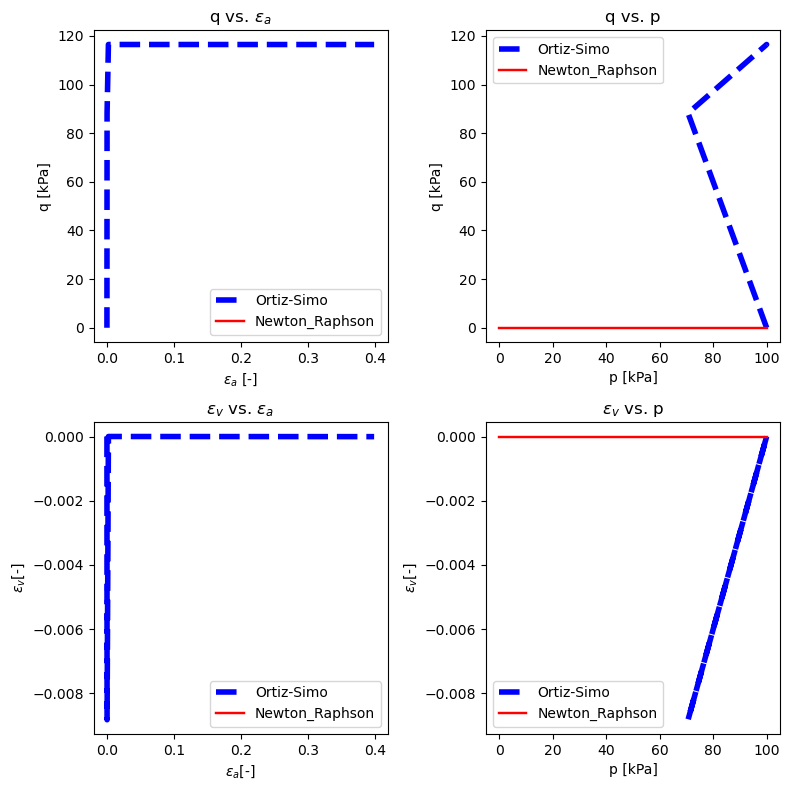

In [45]:
# Generate a figure to plot the MCSS models
fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (8, 8))

colors = ["blue", "red"]
labels = ["Ortiz-Simo", 'Newton_Raphson']
styles = ["dashed", "solid"]
line_widths = [4, 1.75]

for model, color, label, style, linewidth in zip(models, colors, labels, styles, line_widths):
    model.results.quick_quad_plot(axial_strain_id="stran(1)", compression_pos=False, axs = axs, 
                                  color = color , label=label, legend = True, linestyle = style, linewidth = linewidth)
    
plt.show()
# fig.savefig("Drained_Strain_Control_linear_elastic.png", format = "png", bbox_inches = 'tight')
plt.close()

In [14]:
models[0].results.stress_df

,stress(1),stress(2),stress(3),stress(4),stress(5),stress(6)
0,-100.000000,-100.0,-100.0,0.0,0.0,0.0
1,-98.800000,-100.0,-100.0,0.0,0.0,0.0
2,-86.800000,-100.0,-100.0,0.0,0.0,0.0
3,-74.800000,-100.0,-100.0,0.0,0.0,0.0
4,-62.800000,-100.0,-100.0,0.0,0.0,0.0
...,...,...,...,...,...,...
96,-11.764706,-100.0,-100.0,0.0,0.0,0.0
97,-11.764706,-100.0,-100.0,0.0,0.0,0.0
98,-11.764706,-100.0,-100.0,0.0,0.0,0.0
99,-11.764706,-100.0,-100.0,0.0,0.0,0.0


In [15]:
models[1].results.stress_df

,stress(1),stress(2),stress(3),stress(4),stress(5),stress(6)
0,-100.000000,-100.00000,-100.00000,0.0,0.0,0.0
1,-98.800000,-100.00000,-100.00000,0.0,0.0,0.0
2,-86.800000,-100.00000,-100.00000,0.0,0.0,0.0
3,-74.800000,-100.00000,-100.00000,0.0,0.0,0.0
4,-62.800000,-100.00000,-100.00000,0.0,0.0,0.0
...,...,...,...,...,...,...
96,-11.283135,-100.00002,-100.00002,0.0,0.0,0.0
97,-11.283135,-100.00002,-100.00002,0.0,0.0,0.0
98,-11.283135,-100.00002,-100.00002,0.0,0.0,0.0
99,-11.283135,-100.00002,-100.00002,0.0,0.0,0.0


In [16]:
print(models[1].setup)

Constitutive model name: Newton Raphson
Folder path: /mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/2_perf_plastic/Newton_Raphson
Number of stored loads: 1



In [17]:
models[1].setup.properties

{'Init Shear Modulus': 2500,
 'poisson ratio': 0.2,
 'M_tc': 1,
 "Nova's N": 0.0,
 'D_min': 0.0,
 'h': 0,
 'alpha_K': 0.0,
 'alpha_G': 0.0,
 'alpha_D': 0.0,
 'D_part': 0.0,
 'G_s': 0.0,
 'ref_rate': 0.0,
 'switch_smooth': 0.0,
 'Num smoothing': 0.0,
 'switch original': 0.0,
 'FTOl': 1e-08,
 'max stress iters': 1000,
 'switch_plastic_integration': 0}